In [1]:
import PIL.Image as image
import matplotlib.pyplot as plt
import numpy as np

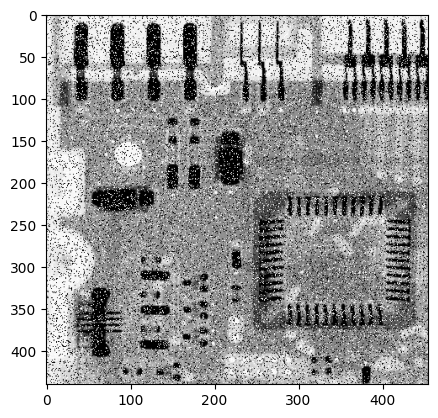

In [19]:

# a) Read a grayscale image
img = image.open('pcb.tif').convert('L')
img_array = np.array(img)
plt.imshow(img_array, cmap="gray")
plt.show()
H,W = img_array.shape

In [20]:
# b) Use replicate padding (edge padding) to handle boundary pixels
filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
])

padded_img = np.pad(img, pad_width=1, mode='edge')

In [21]:
# c) Apply a 3×3 averaging filter to smooth the image
output1 = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        output1[i,j]=np.sum(region * filter)


In [22]:

# d) Apply a 3×3 median filter to smooth the image
output2 = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        output2[i,j]=np.median(region)


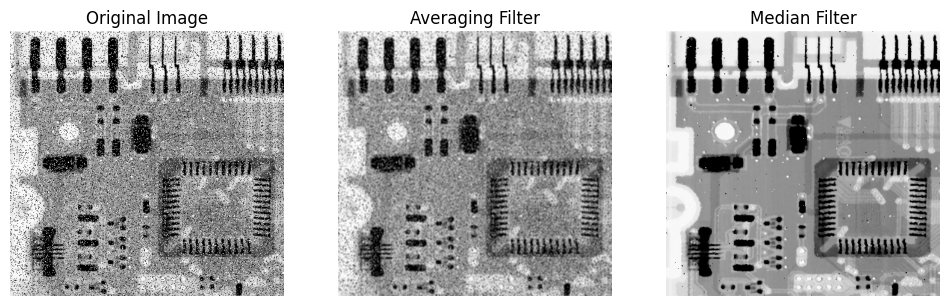

In [24]:
# e) Display the Original image, Averaging filter output, and Median filter output
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(output1,cmap='gray')
plt.title("Averaging Filter")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(output2,cmap='gray')
plt.title("Median Filter")
plt.axis("off")

plt.show()   